# Slope sample — error and time of each batch config

A batch of `N` copies in one `psql` process costs `E(N) = F + b·N`: `b` is the per-copy energy we
want, `F` the fixed per-process overhead. This notebook asks, for each way of estimating `b` from
**one repeat**, how large its error is and how much wall time it costs.

**Configs** (all within one repeat of `N = 1, 2, 4, 8, 16`):

| config | estimate of `b` | batches run |
|---|---|---|
| `{1}` | `E_1` (a single copy alone) | N=1 |
| `{1,N}` | `(E_N − E_1)/(N − 1)` (two-point slope) | N=1 and N |
| `E_N/N` | `E_N / N` (plain batch average) | N |
| `full` | OLS over all five batches | all |

**Data.** 250 SQLStorm queries in seven single-copy energy bands: **reference** (28 queries × 10
repeats — precise enough to be the *truth*) and **breadth** (222 queries × 3 repeats — used to fit
a noise model). Laptop i5-8350U, PostgreSQL 18.4, `tpch_idx`, clock pinned at 2.5 GHz, thermal gate
55–60 °C. Figures go to `figures/slope_sample/`.

## 0. Fetch → `cache/slope_cache/`

SSH/SFTP pull of `logs/slope_sample/` (manifest, orders, per-run CSVs, summaries; `console.log`
skipped) plus, for §7, three files from `logs/sqlstorm/`. Falls back to the cache if the server is
unreachable.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time, stat, math, posixpath
from pathlib import Path
import numpy as np
import pandas as pd

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE    = "/home/user01/GreenSQL/logs/slope_sample"
REMOTE_SS = "/home/user01/GreenSQL/logs/sqlstorm"      # optional, §7 projection only
SS_FILES  = ["query_timing_tpch_idx.csv", "moved_timeouts.txt", "moved_errors.tsv"]
CACHE_DIR = Path("cache/slope_cache")                  # never mixed with cache/ws_cache
RETRIES = 5
KEEP = {"manifest.csv", "summary.txt", "query_timing_tpch_idx.csv",
        "query_samples_tpch_idx.csv", "query_catalog_tpch_idx.csv"}


def _want(fn):
    # manifest + order_* at the top, the per-run CSVs / summary / run_order*; console.log is skipped
    return fn in KEEP or fn.startswith("order_") or fn.startswith("run_order")


def _read(sftp, p):
    with sftp.open(p) as f:
        f.prefetch()
        return f.read()


def _collect(sftp, d, base, blobs):
    for a in sftp.listdir_attr(d):
        p = posixpath.join(d, a.filename)
        if stat.S_ISDIR(a.st_mode):
            _collect(sftp, p, base, blobs)
        elif _want(a.filename):
            blobs[posixpath.relpath(p, base)] = _read(sftp, p)


def fetch_over_ssh():
    import paramiko
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    _collect(sftp, REMOTE, REMOTE, blobs)
                    if not blobs:
                        raise RuntimeError(f"no files under {REMOTE}")
                    for fn in SS_FILES:          # optional -> keys "sqlstorm/<file>"
                        try:
                            blobs[f"sqlstorm/{fn}"] = _read(sftp, f"{REMOTE_SS}/{fn}")
                        except Exception as ss_exc:
                            print(f"  (sqlstorm/{fn} not pulled: {type(ss_exc).__name__})")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        for rel, b in blobs.items():
            fp = CACHE_DIR / rel
            fp.parent.mkdir(parents=True, exist_ok=True)
            fp.write_bytes(b)
        print(f"Fetched {len(blobs)} files from {SSH_HOST}; cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*")
                 if p.is_file() and p.suffix in (".csv", ".txt", ".tsv")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()

Fetched 16 files from 192.168.1.42; cache 'cache\slope_cache/' updated.


## 1. Data and thermal check

One row per measured batch, joined to the manifest band. Worker class: **4w** = 4 parallel workers,
**0-2w** = everything else. The two reference rows killed by an OS upgrade (9307.sql, one repeat,
`N=8/16`) are dropped; breadth repeats without `N=16` were capped at run time (single copy > 6 s).

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "axes.grid": True,
                     "grid.color": "#e6e6e6", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures/slope_sample"); FIG.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


BAND_ORDER = ["0-2", "2-7.5", "7.5-15", "15-40", "40-75", "75-120", ">120"]
BAND_EDGES = [0, 2, 7.5, 15, 40, 75, 120, np.inf]
BAND_COLOR = dict(zip(BAND_ORDER, plt.cm.viridis(np.linspace(0.0, 0.92, len(BAND_ORDER)))))
WCOLOR = {"4w": "#d62728", "0-2w": "#1f77b4"}
NS = [1, 2, 4, 8, 16]


def read(key, **kw):
    return pd.read_csv(io.BytesIO(BLOBS[key]), **kw)


TIER_DIRS = {}                       # warm_stepup/<tier>_<stamp>/ (latest stamp wins)
for key in sorted(BLOBS):
    m = re.match(r"warm_stepup/(reference|breadth)_[^/]+/query_timing_tpch_idx\.csv$", key)
    if m:
        TIER_DIRS[m.group(1)] = posixpath.dirname(key)
assert set(TIER_DIRS) == {"reference", "breadth"}, TIER_DIRS

MAN = read("manifest.csv")
MAN["qid"] = MAN["staged"].map(posixpath.basename)
MAN["band"] = MAN["band"].str.replace("J", "", regex=False).str.strip()
assert set(MAN["band"]) == set(BAND_ORDER), set(MAN["band"])

NUM = ["batchnum", "batch_index", "elapsed_sec", "rapl_pkg_j", "failed", "mhz_mean",
       "pkg_temp_max_c", "throttle_core_delta", "throttle_pkg_delta", "preheat_s",
       "cooldown_wait_s", "idle_before_s"]
RAW = {}
for tier, d in TIER_DIRS.items():
    t = read(f"{d}/query_timing_tpch_idx.csv")
    for c in NUM:
        t[c] = pd.to_numeric(t[c], errors="coerce")
    t["ts"] = pd.to_datetime(t["timestamp_utc"])
    t["tier"] = tier
    t["qid"] = t["query"].map(posixpath.basename)
    RAW[tier] = t
MEAS = {k: v[v["phase"] == "measured"] for k, v in RAW.items()}
FAILED = pd.concat([v[v["failed"] == 1] for v in MEAS.values()])

# the counts the run should have produced
r_, b_ = MEAS["reference"], MEAS["breadth"]
assert len(r_) == 1400 and r_["qid"].nunique() == 28 and (r_.groupby("qid")["run_id"].nunique() == 10).all()
fr = FAILED[FAILED["tier"] == "reference"]
assert len(fr) == 2 and set(fr["qid"]) == {"9307.sql"} and fr["run_id"].nunique() == 1 \
    and set(fr["batchnum"]) == {8, 16}, fr
assert len(b_) == 3079 and b_["qid"].nunique() == 222 and (b_.groupby("qid")["run_id"].nunique() == 3).all()
assert (b_["failed"] == 1).sum() == 0
assert MAN[MAN["tier"] == "breadth"]["band"].value_counts().reindex(BAND_ORDER).tolist() \
    == [30, 30, 30, 30, 30, 36, 36]
assert (MAN[MAN["tier"] == "reference"]["band"].value_counts().reindex(BAND_ORDER) == 4).all()
for tier in TIER_DIRS:
    assert set(MEAS[tier]["qid"]) == set(MAN[MAN["tier"] == tier]["qid"]), tier


def workers(tier):
    s = read(f"{TIER_DIRS[tier]}/query_samples_tpch_idx.csv",
             usecols=["query", "phase", "batchnum", "workers_launched"])
    s = s[(s["phase"] == "measured") & (pd.to_numeric(s["batchnum"], errors="coerce") == 1)]
    wl = pd.to_numeric(s["workers_launched"], errors="coerce")
    return wl.groupby(s["query"].map(posixpath.basename)).max()


W = pd.concat([workers(t).rename("workers").rename_axis("qid").reset_index().assign(tier=t)
               for t in TIER_DIRS])
D = pd.concat([MEAS[t][MEAS[t]["failed"] != 1] for t in MEAS], ignore_index=True)
D = D.rename(columns={"run_id": "rep", "batchnum": "N", "rapl_pkg_j": "E", "elapsed_sec": "t"})
D["N"] = D["N"].astype(int)
D = D.merge(MAN[["tier", "qid", "band"]], on=["tier", "qid"], how="left")
D = D.merge(W, on=["tier", "qid"], how="left")
D["wclass"] = np.where(D["workers"] == 4, "4w", "0-2w")
D["band"] = pd.Categorical(D["band"], BAND_ORDER, ordered=True)
D["thr_any"] = (D["throttle_core_delta"].fillna(0) > 0) | (D["throttle_pkg_delta"].fillna(0) > 0)
assert len(D) == 1398 + 3079 and D["band"].notna().all()

# capping: from the batch sizes present per run_id (breadth only)
has16 = D[D["tier"] == "breadth"].groupby(["qid", "rep"])["N"].agg(lambda s: 16 in set(s))
ncap = (~has16).groupby(level="qid").sum()
CAPPED = set(ncap[ncap == 3].index)
MIXED = set(ncap[(ncap > 0) & (ncap < 3)].index)


def ols(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2 or np.ptp(x[m]) == 0:
        return np.nan, np.nan
    b, a = np.polyfit(x[m], y[m], 1)
    return b, a


def spearman(a, b):
    a = pd.Series(np.asarray(a, float)); b = pd.Series(np.asarray(b, float))
    m = a.notna() & b.notna() & np.isfinite(a) & np.isfinite(b)
    return a[m].rank().corr(b[m].rank())


rows = []                            # per-query fit over all repeats (reference 10, breadth 3)
for (tier, qid), g in D.groupby(["tier", "qid"]):
    b, a = ols(g["N"], g["E"])
    n1 = g[g["N"] == 1]
    E1, t1 = n1["E"].mean(), n1["t"].mean()
    rows.append(dict(tier=tier, qid=qid, band=g["band"].iloc[0], wclass=g["wclass"].iloc[0],
                     n_rep=g["rep"].nunique(), E1=E1, t1=t1, b=b, a=a, F=E1 - b, P=E1 / t1,
                     capped=qid in CAPPED and tier == "breadth"))
Q = pd.DataFrame(rows)
Q["band"] = pd.Categorical(Q["band"], BAND_ORDER, ordered=True)
print(f"{len(D)} measured batches, {len(Q)} queries (reference 28 x 10 repeats, breadth 222 x 3); "
      f"{len(CAPPED)} breadth queries capped at N=8 (+{len(MIXED)} in some repeats); "
      f"all count checks passed")

4477 measured batches, 250 queries (reference 28 x 10 repeats, breadth 222 x 3); 83 breadth queries capped at N=8 (+1 in some repeats); all count checks passed


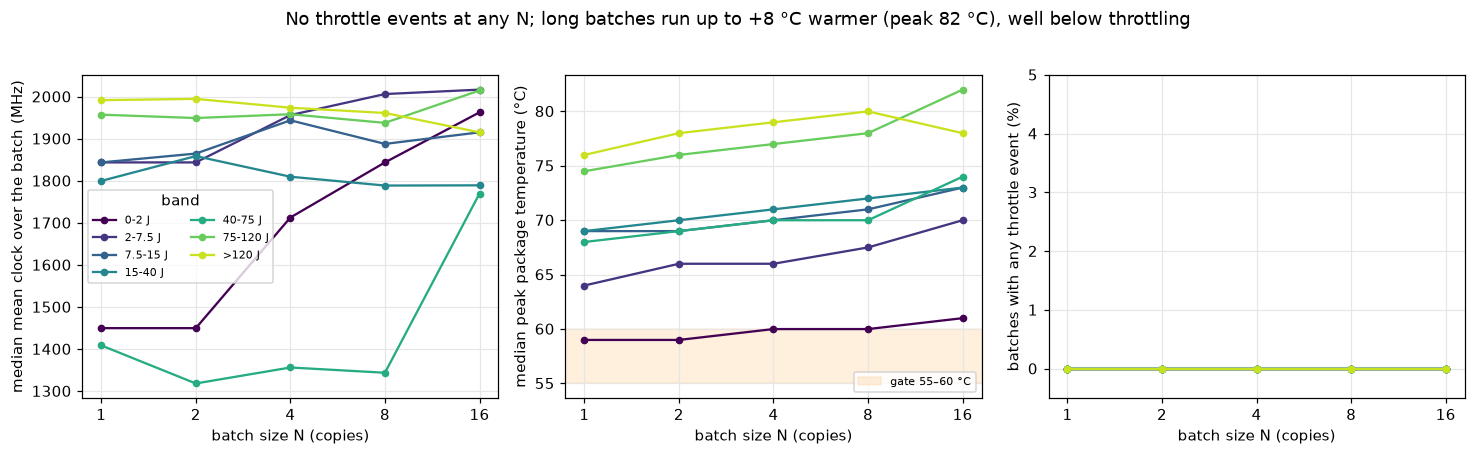

In [3]:
qc = (D.groupby(["band", "N"], observed=True)
        .agg(mhz=("mhz_mean", "median"), tmax=("pkg_temp_max_c", "median"),
             thr=("thr_any", "mean")).reset_index())
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for bn in BAND_ORDER:
    s = qc[qc["band"] == bn]
    axes[0].plot(s["N"], s["mhz"], marker="o", ms=4, color=BAND_COLOR[bn], label=f"{bn} J")
    axes[1].plot(s["N"], s["tmax"], marker="o", ms=4, color=BAND_COLOR[bn])
    axes[2].plot(s["N"], 100 * s["thr"], marker="o", ms=4, color=BAND_COLOR[bn])
for ax, yl in zip(axes, ["median mean clock over the batch (MHz)",
                         "median peak package temperature (°C)",
                         "batches with any throttle event (%)"]):
    ax.set_xscale("log", base=2); ax.set_xticks(NS); ax.set_xticklabels(NS)
    ax.set_xlabel("batch size N (copies)"); ax.set_ylabel(yl)
axes[1].axhspan(55, 60, color="#fdd49e", alpha=0.35, zorder=0, label="gate 55–60 °C")
axes[1].legend(fontsize=7.5, loc="lower right")
axes[2].set_ylim(-0.5, max(5, 100 * qc["thr"].max() * 1.2))
axes[0].legend(title="band", fontsize=7.5, ncol=2)
piv = qc.pivot(index="band", columns="N", values="tmax")
N_THR = int(D["thr_any"].sum())
T_RISE = (piv[16] - piv[1]).max()
T_PEAK = piv.max().max()
fig.suptitle(f"{'No' if N_THR == 0 else N_THR} throttle events at any N; long batches run up to "
             f"+{T_RISE:.0f} °C warmer (peak {T_PEAK:.0f} °C), well below throttling",
             fontsize=12, y=1.02)
fig.tight_layout(); savefig(fig, "qc_thermal_vs_N"); plt.show()

## 2. Truth, configs, and linearity

**Truth.** For each reference query and repeat, the config's estimate is scored against `b_ref` =
the OLS slope over the **other 9 repeats** (leave-one-repeat-out), so a repeat never scores
itself. Error = `(estimate − b_ref)/b_ref`.

**Linearity.** Two-point slopes to different `N` estimate the same `b` only if `E(N)` is a straight
line. Left: residuals of the 10-repeat fit as a share of the batch's per-copy energy. Right: the
batch average `E_N/N` relative to `b`, which on a straight line falls as `1 + F/(b·N)`.

In [4]:
REF = D[D["tier"] == "reference"]
rng = np.random.default_rng(20260922)
B_BOOT = 2000


def rep_sums(g):
    """per-repeat sufficient statistics (n, Σx, Σy, Σxx, Σxy) for OLS of E on N."""
    return np.array([[len(x), x["N"].sum(), x["E"].sum(), (x["N"] ** 2).sum(),
                      (x["N"] * x["E"]).sum()] for _, x in g.groupby("rep")], float)


def slope_from_sums(T):
    n, sx, sy, sxx, sxy = np.moveaxis(T, -1, 0)
    return (n * sxy - sx * sy) / (n * sxx - sx ** 2)


rows = []
for qid, g in REF.groupby("qid"):
    b, a = ols(g["N"], g["E"])
    S = rep_sums(g)
    se_boot = slope_from_sums(S[rng.integers(0, len(S), (B_BOOT, len(S)))].sum(axis=1)).std(ddof=1)
    E1 = g[g["N"] == 1]["E"].mean()
    rows.append(dict(qid=qid, band=g["band"].iloc[0], E1=E1, b_true=b, a=a, F=E1 - b,
                     rse_pct=100 * se_boot / b))
TRUTH = pd.DataFrame(rows)
TRUTH["band"] = pd.Categorical(TRUTH["band"], BAND_ORDER, ordered=True)


def w_full(ns=NS):
    x = np.array(ns, float)
    w = np.zeros(len(NS))
    w[[NS.index(n) for n in ns]] = (x - x.mean()) / ((x - x.mean()) ** 2).sum()
    return w


def w_design(d):
    """each config is a linear combination w of one repeat's (E_1, E_2, E_4, E_8, E_16)."""
    w = np.zeros(len(NS))
    if d == "{1}":
        w[0] = 1.0
    elif d.startswith("{1,"):
        N = int(d[3:-1]); w[0] = -1 / (N - 1); w[NS.index(N)] = 1 / (N - 1)
    elif d.startswith("E"):
        N = int(d[1:d.index("/")]); w[NS.index(N)] = 1 / N
    elif d == "full":
        w = w_full()
    return w


DESIGNS = ["{1}", "{1,2}", "{1,4}", "{1,8}", "{1,16}", "E2/2", "E4/4", "E8/8", "E16/16", "full"]
WD = {d: w_design(d) for d in DESIGNS}
DESIGN_NS = {d: [n for n, w in zip(NS, WD[d]) if w != 0] for d in DESIGNS}
DCOLOR = {"{1}": "#111111", "{1,2}": "#c6dbef", "{1,4}": "#6baed6", "{1,8}": "#2171b5",
          "{1,16}": "#08306b", "E2/2": "#fdd0a2", "E4/4": "#fd8d3c", "E8/8": "#d94801",
          "E16/16": "#7f2704", "full": "#238b45"}

PIV = D.pivot_table(index=["tier", "qid", "rep"], columns="N", values="E").reindex(columns=NS)
X = PIV.to_numpy()
est = {}
for d in DESIGNS:                    # NaN when a needed batch is missing
    used = WD[d] != 0
    est[d] = np.where(np.isnan(X[:, used]).any(axis=1), np.nan,
                      np.nan_to_num(X[:, used]) @ WD[d][used])
EST = pd.DataFrame(est, index=PIV.index).reset_index().melt(
    id_vars=["tier", "qid", "rep"], var_name="design", value_name="est")

LOO = pd.DataFrame([dict(qid=qid, rep=rep, b_ref=ols(g[g["rep"] != rep]["N"],
                                                     g[g["rep"] != rep]["E"])[0])
                    for qid, g in REF.groupby("qid") for rep in g["rep"].unique()])
ERR = (EST[EST["tier"] == "reference"].merge(LOO, on=["qid", "rep"])
       .merge(TRUTH[["qid", "band", "E1", "b_true", "F"]], on="qid").dropna(subset=["est"]))
ERR["err"] = (ERR["est"] - ERR["b_ref"]) / ERR["b_ref"]
ERR["abs"] = ERR["err"].abs()
ERR["design"] = pd.Categorical(ERR["design"], DESIGNS, ordered=True)
RATIO_TRUTH = (ERR[ERR["design"] == "{1,16}"].groupby("qid")["abs"].median() * 100
               / TRUTH.set_index("qid")["rse_pct"]).median()
print(f"truth precision: median relative SE of the 10-repeat slope {TRUTH['rse_pct'].median():.2f}% "
      f"(bootstrap over repeats) — {RATIO_TRUTH:.0f}x smaller than even the {{1,16}} error")

truth precision: median relative SE of the 10-repeat slope 0.18% (bootstrap over repeats) — 2x smaller than even the {1,16} error


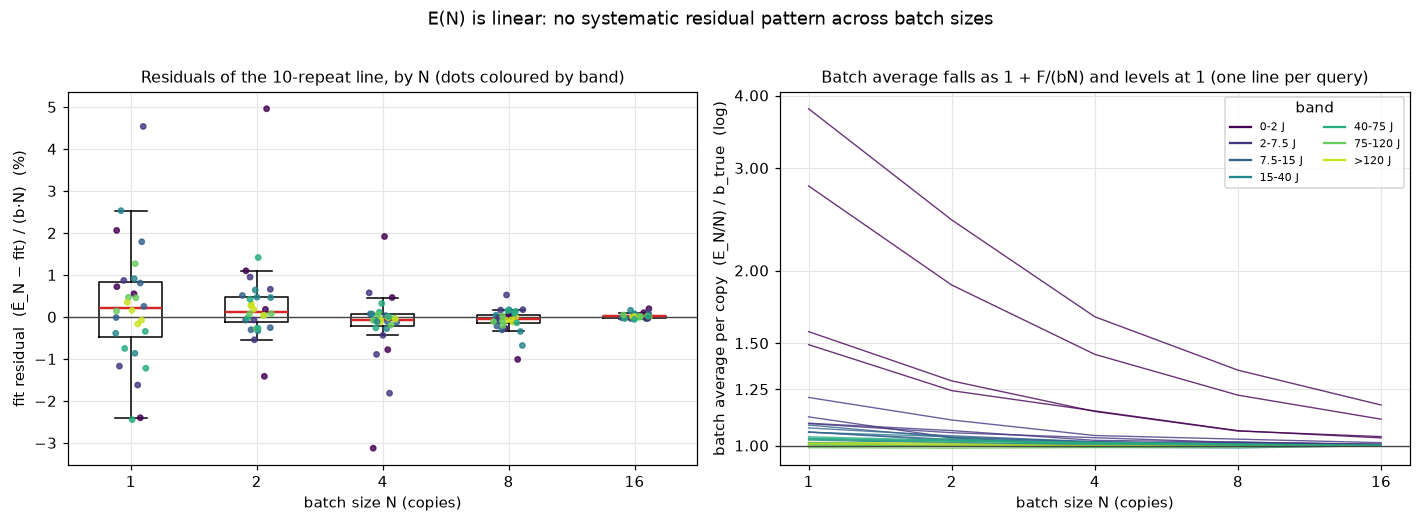

curvature κ = s(4,8,16)/s(1,2,4) − 1: median +0.17%; 5 of 28 queries significant and >1% (2-7.5, 0-2, 2-7.5, 0-2, 40-75 J); heavy bands median +0.18% (the warmer long batches)


In [5]:
rows = []
for _, tr in TRUTH.iterrows():
    mE = REF[REF["qid"] == tr["qid"]].groupby("N")["E"].mean()
    for N, e in mE.items():
        rows.append(dict(qid=tr["qid"], band=tr["band"], N=N,
                         resid=100 * (e - (tr["a"] + tr["b_true"] * N)) / (tr["b_true"] * N),
                         avg_ratio=(e / N) / tr["b_true"]))
LIN = pd.DataFrame(rows)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
pos = np.arange(len(NS))
a1.boxplot([LIN[LIN["N"] == N]["resid"] for N in NS], positions=pos, widths=0.5,
           showfliers=False, medianprops=dict(color="#d62728", lw=1.6))
for i, N in enumerate(NS):
    s = LIN[LIN["N"] == N]
    a1.scatter(i + np.random.default_rng(i).uniform(-0.12, 0.12, len(s)), s["resid"], s=12,
               c=[BAND_COLOR[b] for b in s["band"]], alpha=0.8, zorder=3)
a1.axhline(0, color="#444", lw=0.9)
a1.set_xticks(pos); a1.set_xticklabels(NS)
a1.set_xlabel("batch size N (copies)")
a1.set_ylabel("fit residual  (Ē_N − fit) / (b·N)  (%)")
a1.set_title("Residuals of the 10-repeat line, by N (dots coloured by band)", fontsize=10.5)
for qid, s in LIN.groupby("qid"):
    a2.plot(s["N"], s["avg_ratio"], color=BAND_COLOR[s["band"].iloc[0]], lw=0.9, alpha=0.8)
a2.axhline(1, color="#444", lw=0.9)
a2.set_xscale("log", base=2); a2.set_xticks(NS); a2.set_xticklabels(NS); a2.set_yscale("log")
a2.set_yticks([1, 1.25, 1.5, 2, 3, 4]); a2.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
a2.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
a2.set_xlabel("batch size N (copies)")
a2.set_ylabel("batch average per copy  (E_N/N) / b_true  (log)")
a2.set_title("Batch average falls as 1 + F/(bN) and levels at 1 (one line per query)",
             fontsize=10.5)
for bn in BAND_ORDER:
    a2.plot([], [], color=BAND_COLOR[bn], label=f"{bn} J")
a2.legend(fontsize=7, ncol=2, title="band")
fig.suptitle("E(N) is linear: no systematic residual pattern across batch sizes", fontsize=12,
             y=1.02)
fig.tight_layout(); savefig(fig, "linearity"); plt.show()

# curvature: slope over {4,8,16} vs {1,2,4}, bootstrap over repeats
rows = []
for qid, g in REF.groupby("qid"):
    both = sorted(r for r, x in g.groupby("rep") if set(NS) <= set(x["N"]))
    gl = g[g["rep"].isin(both)]
    Slo, Shi = rep_sums(gl[gl["N"].isin([1, 2, 4])]), rep_sums(gl[gl["N"].isin([4, 8, 16])])
    k_hat = slope_from_sums(Shi.sum(0)) / slope_from_sums(Slo.sum(0)) - 1
    idx = rng.integers(0, len(both), (B_BOOT, len(both)))
    lo, hi = np.percentile(slope_from_sums(Shi[idx].sum(1)) / slope_from_sums(Slo[idx].sum(1)) - 1,
                           [2.5, 97.5])
    rows.append(dict(qid=qid, band=g["band"].iloc[0], kappa_pct=100 * k_hat,
                     flag=(lo > 0 or hi < 0) and abs(k_hat) > 0.01))
CURV = pd.DataFrame(rows)
N_CURV = int(CURV["flag"].sum())
HEAVY_K = CURV[CURV["band"].isin(["75-120", ">120"])]["kappa_pct"]
print(f"curvature κ = s(4,8,16)/s(1,2,4) − 1: median {CURV['kappa_pct'].median():+.2f}%; "
      f"{N_CURV} of 28 queries significant and >1% ({', '.join(CURV[CURV['flag']]['band'].astype(str))} J); "
      f"heavy bands median {HEAVY_K.median():+.2f}% (the warmer long batches)")

## 3. Error of each config

Single-repeat error against the leave-one-out truth, per energy band (4 reference queries × 10
repeats per cell). Median = the typical repeat; p90 = 9 repeats in 10 are at least this good.

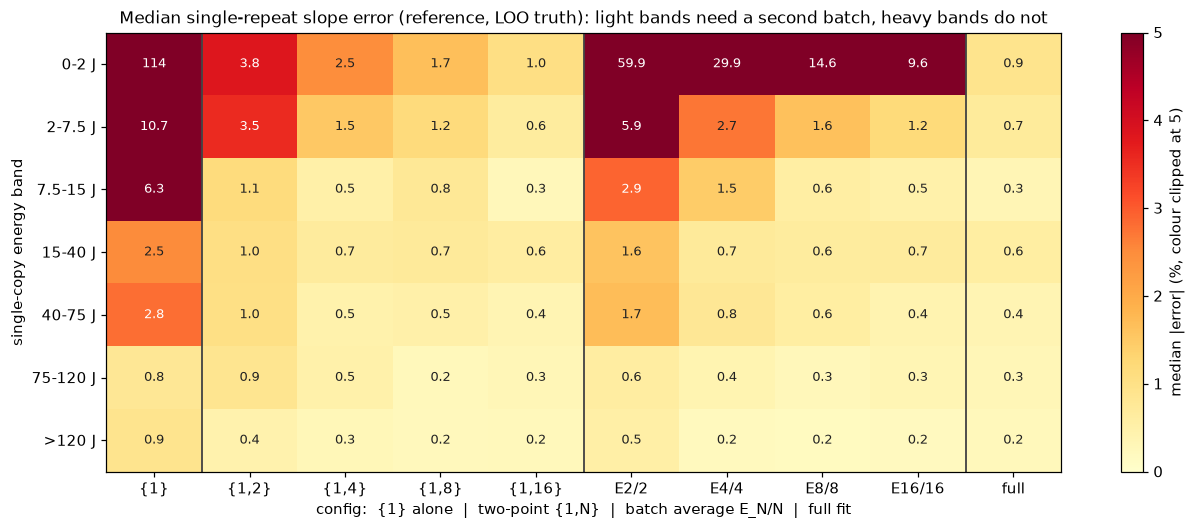

In [6]:
def heat(M, title, name, vmax, cbl, vmin=0, cmap="YlOrRd", fmt=None):
    fig, ax = plt.subplots(figsize=(12, 4.9))
    ax.grid(False)
    im = ax.imshow(M.to_numpy(float), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(M.columns)
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels([f"{b} J" for b in M.index])
    for xv in (0.5, 4.5, 8.5):          # {1} | two-point | batch average | full fit
        ax.axvline(xv, color="#444444", lw=1.2)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iat[i, j]
            if np.isfinite(v):
                txt = fmt(v) if fmt else (f"{v:.1f}" if v < 100 else f"{v:.0f}")
                ax.text(j, i, txt, ha="center", va="center", fontsize=8.5,
                        color="white" if v > vmin + 0.55 * (vmax - vmin) else "#222222")
    ax.set_xlabel("config:  {1} alone  |  two-point {1,N}  |  batch average E_N/N  |  full fit")
    ax.set_ylabel("single-copy energy band")
    cb = fig.colorbar(im, ax=ax); cb.set_label(cbl)
    ax.set_title(title, fontsize=11)
    fig.tight_layout(); savefig(fig, name); plt.show()


g_ = ERR.groupby(["band", "design"], observed=True)["abs"]
HMED = (g_.median() * 100).unstack().reindex(index=BAND_ORDER, columns=DESIGNS)
HP90 = (g_.quantile(0.9) * 100).unstack().reindex(index=BAND_ORDER, columns=DESIGNS)
heat(HMED, "Median single-repeat slope error (reference, LOO truth): light bands need a "
     "second batch, heavy bands do not", "heatmap_median", 5,
     "median |error| (%, colour clipped at 5)")

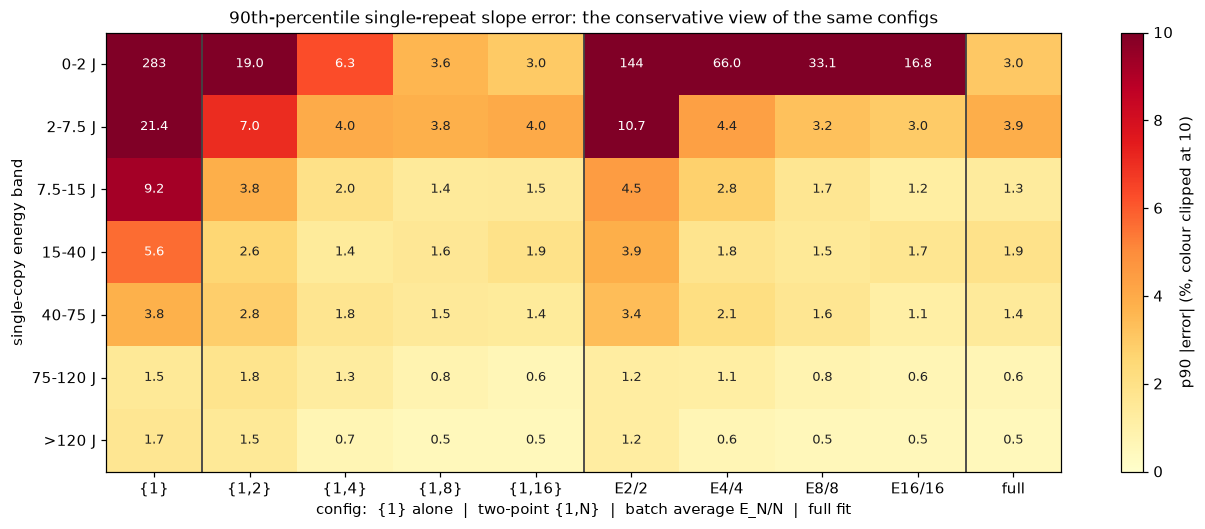

In [7]:
heat(HP90, "90th-percentile single-repeat slope error: the conservative view of the same "
     "configs", "heatmap_p90", 10, "p90 |error| (%, colour clipped at 10)")

### 3a. `{1}` error vs single-copy energy

Each point is one repeat's signed `{1}` error. A fixed overhead `F_med` would give
`F_med/(E1 − F_med)` ≈ `F_med/E1`. Open markers are negative errors (noise on heavy queries).

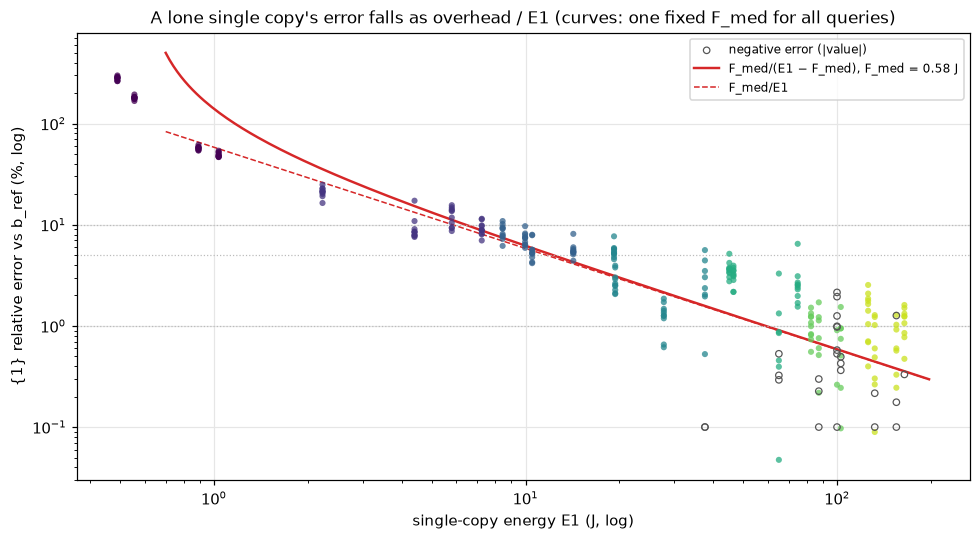

In [8]:
e1 = ERR[ERR["design"] == "{1}"]
F_MED_REF = TRUTH["F"].median()
fig, ax = plt.subplots(figsize=(9, 5))
pos_, neg_ = e1[e1["err"] > 0], e1[e1["err"] <= 0]
ax.scatter(pos_["E1"], 100 * pos_["err"], s=16, c=[BAND_COLOR[b] for b in pos_["band"]],
           alpha=0.75, edgecolor="none", zorder=3)
ax.scatter(neg_["E1"], 100 * neg_["err"].abs().clip(lower=1e-3), s=18, facecolor="none",
           edgecolor="#555", lw=0.8, zorder=3, label="negative error (|value|)")
xs = np.logspace(np.log10(max(e1["E1"].min() * 0.8, F_MED_REF * 1.2)),
                 np.log10(e1["E1"].max() * 1.2), 200)
ax.plot(xs, 100 * F_MED_REF / (xs - F_MED_REF), color="#d62728", lw=1.6,
        label=f"F_med/(E1 − F_med), F_med = {F_MED_REF:.2f} J")
ax.plot(xs, 100 * F_MED_REF / xs, color="#d62728", lw=1.0, ls="--", label="F_med/E1")
for yv in (10, 5, 1):
    ax.axhline(yv, color="#bbbbbb", lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("single-copy energy E1 (J, log)")
ax.set_ylabel("{1} relative error vs b_ref (%, log)")
ax.legend(fontsize=8)
ax.set_title("A lone single copy's error falls as overhead / E1 (curves: one fixed F_med for all "
             "queries)", fontsize=11)
fig.tight_layout(); savefig(fig, "single_copy_error_vs_e1"); plt.show()

## 4. Why the errors look like this — overhead and noise

Four checks, fitted on the 222 breadth queries: is the overhead `F` a fixed number of joules;
is the overhead share driven by energy or by time; how noisy is a batch; and does a noise model
built from these reproduce the reference errors of §3? The model is then used to predict every
config's error for all 250 queries (§6).

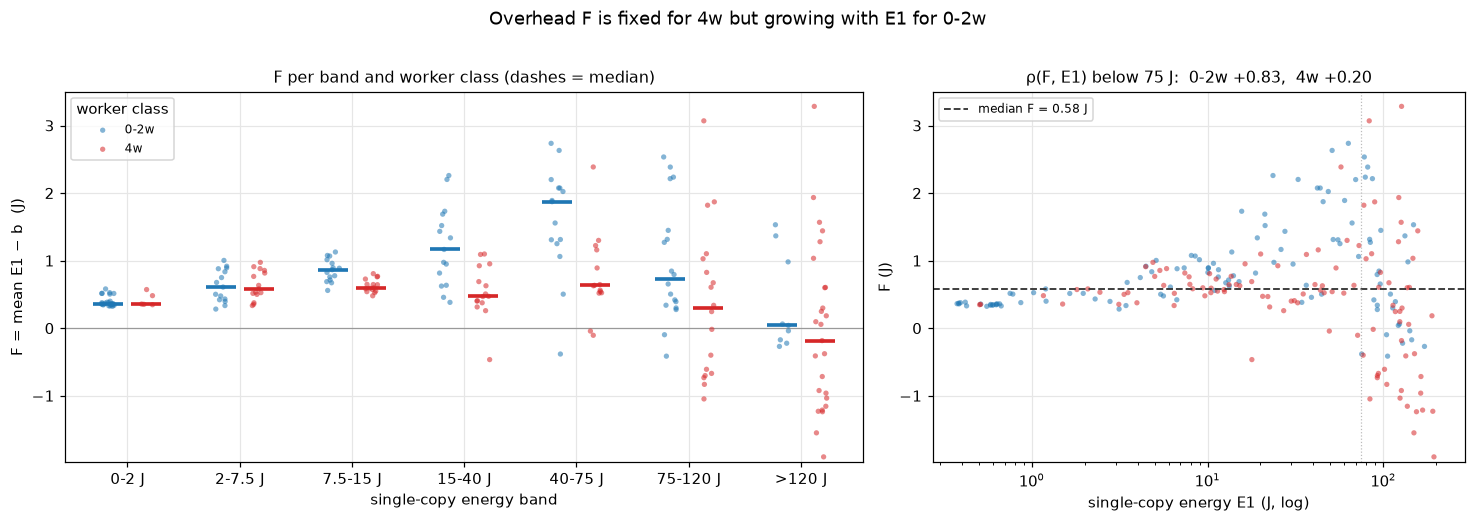

In [9]:
BQ = Q[Q["tier"] == "breadth"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
for i, bn in enumerate(BAND_ORDER):
    for j, cl in enumerate(["0-2w", "4w"]):
        s = BQ[(BQ["band"] == bn) & (BQ["wclass"] == cl)]["F"]
        x = i + (j - 0.5) * 0.34 + np.random.default_rng(10 * i + j).uniform(-0.06, 0.06, len(s))
        a1.scatter(x, s, s=12, color=WCOLOR[cl], alpha=0.55, edgecolor="none",
                   label=cl if i == 0 else None, zorder=3)
        if len(s):
            a1.plot([i + (j - 0.5) * 0.34], [s.median()], marker="_", ms=20, mew=2.4,
                    color=WCOLOR[cl], zorder=4)
a1.axhline(0, color="#999", lw=0.8)
a1.set_xticks(range(len(BAND_ORDER))); a1.set_xticklabels([f"{b} J" for b in BAND_ORDER])
a1.set_xlabel("single-copy energy band"); a1.set_ylabel("F = mean E1 − b  (J)")
a1.set_ylim(np.percentile(BQ["F"], 1) - 0.5, np.percentile(BQ["F"], 99) + 0.5)
a1.legend(title="worker class", fontsize=8)
a1.set_title("F per band and worker class (dashes = median)", fontsize=10.5)
for cl in ["0-2w", "4w"]:
    s = BQ[BQ["wclass"] == cl]
    a2.scatter(s["E1"], s["F"], s=12, color=WCOLOR[cl], alpha=0.55, edgecolor="none")
a2.axhline(BQ["F"].median(), color="#333", lw=1.2, ls="--",
           label=f"median F = {BQ['F'].median():.2f} J")
a2.axvline(75, color="#bbbbbb", lw=0.8, ls=":")
a2.set_xscale("log"); a2.set_ylim(a1.get_ylim())
a2.set_xlabel("single-copy energy E1 (J, log)"); a2.set_ylabel("F (J)")
a2.legend(fontsize=8)
# is F fixed? Spearman of F against E1 per worker class, below 75 J where F is well determined
RHO_F = {cl: spearman(Q[(Q["wclass"] == cl) & (Q["E1"] < 75)]["F"],
                      Q[(Q["wclass"] == cl) & (Q["E1"] < 75)]["E1"]) for cl in ["0-2w", "4w"]}
FIXED = {cl: abs(r) < 0.3 for cl, r in RHO_F.items()}
a2.set_title("ρ(F, E1) below 75 J:  " + ",  ".join(f"{cl} {r:+.2f}" for cl, r in RHO_F.items()),
             fontsize=10.5)
sup = ("Per-process overhead is a fixed number of joules in both worker classes"
       if all(FIXED.values()) else "Overhead F is " + " but ".join(
           f"{'fixed' if FIXED[cl] else 'growing with E1'} for {cl}" for cl in ["4w", "0-2w"]))
fig.suptitle(sup, fontsize=12, y=1.02)
fig.tight_layout(); savefig(fig, "overhead_F_breadth"); plt.show()
F_MED, F_P75 = Q["F"].median(), Q["F"].quantile(0.75)

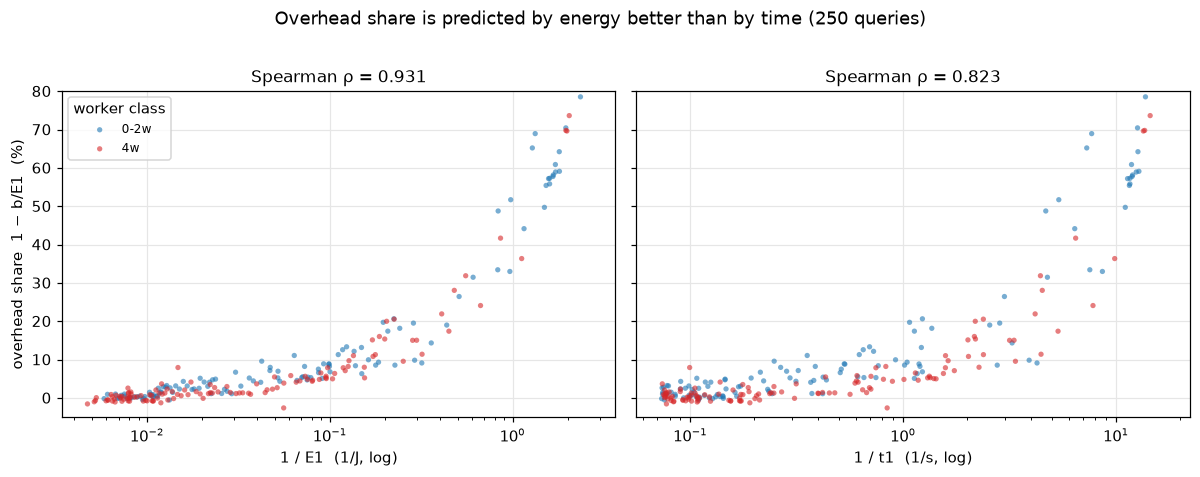

In [10]:
osh = 1 - Q["b"] / Q["E1"]
RHO_E, RHO_T = spearman(osh, 1 / Q["E1"]), spearman(osh, 1 / Q["t1"])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, xv, lab, r in [(a1, 1 / Q["E1"], "1 / E1  (1/J, log)", RHO_E),
                       (a2, 1 / Q["t1"], "1 / t1  (1/s, log)", RHO_T)]:
    for cl in ["0-2w", "4w"]:
        m = Q["wclass"] == cl
        ax.scatter(xv[m], 100 * osh[m], s=12, color=WCOLOR[cl], alpha=0.6, edgecolor="none",
                   label=cl)
    ax.set_xscale("log"); ax.set_xlabel(lab); ax.set_title(f"Spearman ρ = {r:.3f}", fontsize=11)
a1.set_ylabel("overhead share  1 − b/E1  (%)"); a1.legend(title="worker class", fontsize=8)
a1.set_ylim(-5, 80)
fig.suptitle("Overhead share is predicted by energy " +
             ("better than" if RHO_E > RHO_T else "no better than") + " by time (250 queries)",
             fontsize=12, y=1.02)
fig.tight_layout(); savefig(fig, "overhead_share_energy_vs_time"); plt.show()

**Noise model.** `σ²(E) = s0² + (c·E)²` fitted to the per-(query, N) variances across the breadth
repeats, plus the within-repeat correlation `R` between batch sizes. Every config is a linear
combination `w` of a repeat's five batch energies, so its predicted relative bias is
`(w·E − b)/b` and its SD is `√(wᵀΣw)/b` with `Σ_ij = R_ij σ_i σ_j`.

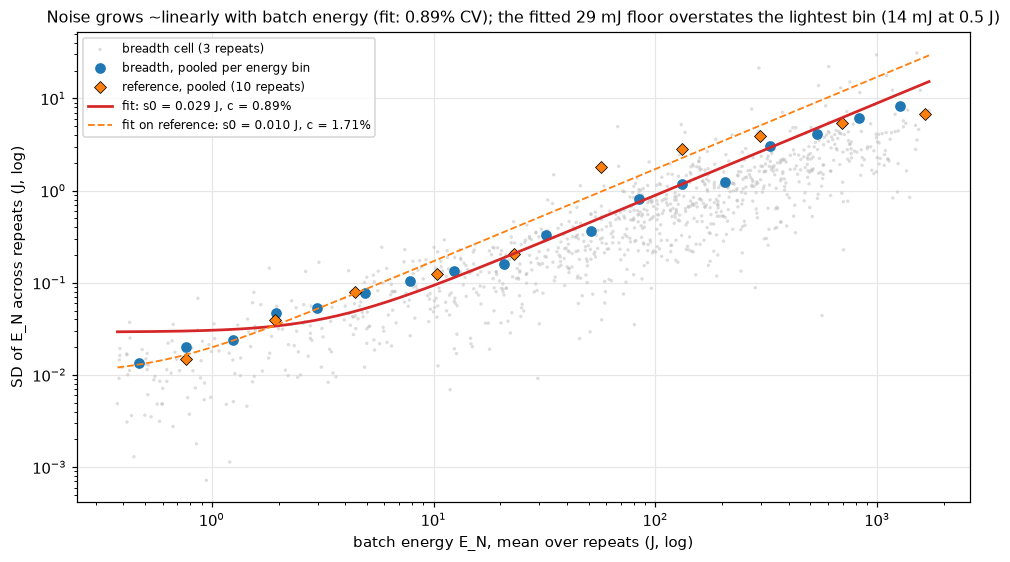

noise: s0 = 29 mJ, c = 0.89%;  within-repeat ρ(E_1, E_N) = +0.41 / +0.32 / +0.25 / +0.14  for N = 2 / 4 / 8 / 16


In [11]:
def cell_var(df):
    v = df.groupby(["qid", "N"])["E"].agg(["mean", "var", "count"]).reset_index()
    return v[v["count"] >= 2]


def fit_sigma(V, iters=40):
    """IRLS on per-cell variances, weights df/σ⁴ (the variance of a sample variance)."""
    x = V["mean"].to_numpy(); v = V["var"].to_numpy(); dfree = V["count"].to_numpy() - 1
    A = np.c_[np.ones_like(x), x ** 2]
    th = np.array([max(np.median(v[x < np.percentile(x, 10)]), 1e-6), 1e-4])
    for _ in range(iters):
        pred = np.maximum(A @ th, 1e-12)
        sw = np.sqrt(dfree) / pred
        th, *_ = np.linalg.lstsq(A * sw[:, None], v * sw, rcond=None)
        th = np.maximum(th, 1e-12)
    return np.sqrt(th[0]), np.sqrt(th[1])


VB, VR = cell_var(D[D["tier"] == "breadth"]), cell_var(REF)
S0, CV = fit_sigma(VB)
S0_R, CV_R = fit_sigma(VR)


def sigma(E, s0=None, c=None):
    s0 = S0 if s0 is None else s0; c = CV if c is None else c
    return np.sqrt(s0 ** 2 + (c * np.asarray(E, float)) ** 2)


def binned(V, nb=18):
    edges = np.logspace(np.log10(V["mean"].min()), np.log10(V["mean"].max()) + 1e-9, nb + 1)
    g = V.groupby(np.digitize(V["mean"], edges) - 1)
    return pd.DataFrame({"E": g["mean"].apply(lambda s: np.exp(np.log(s).mean())),
                         "sd": np.sqrt(g["var"].mean())})


fig, ax = plt.subplots(figsize=(9, 5.2))
ax.scatter(VB["mean"], np.sqrt(VB["var"]), s=5, color="#bdbdbd", alpha=0.5, edgecolor="none",
           label="breadth cell (3 repeats)")
bb, br = binned(VB), binned(VR, 10)
ax.plot(bb["E"], bb["sd"], "o", color="#1f77b4", ms=6, label="breadth, pooled per energy bin")
ax.plot(br["E"], br["sd"], "D", color="#ff7f0e", ms=6, mec="black", mew=0.5,
        label="reference, pooled (10 repeats)")
xs = np.logspace(np.log10(VB["mean"].min()), np.log10(VB["mean"].max()), 200)
ax.plot(xs, sigma(xs), color="#d62728", lw=1.8, label=f"fit: s0 = {S0:.3f} J, c = {100 * CV:.2f}%")
ax.plot(xs, sigma(xs, S0_R, CV_R), color="#ff7f0e", lw=1.2, ls="--",
        label=f"fit on reference: s0 = {S0_R:.3f} J, c = {100 * CV_R:.2f}%")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("batch energy E_N, mean over repeats (J, log)")
ax.set_ylabel("SD of E_N across repeats (J, log)")
ax.legend(fontsize=8)
SD_LOW, E_LOW = bb["sd"].iloc[0], bb["E"].iloc[0]
ax.set_title(f"Noise grows ~linearly with batch energy (fit: {100 * CV:.2f}% CV); the fitted "
             f"{1000 * S0:.0f} mJ floor " + ("overstates" if sigma(E_LOW) > 1.5 * SD_LOW else "matches") +
             f" the lightest bin ({1000 * SD_LOW:.0f} mJ at {E_LOW:.1f} J)", fontsize=10.5)
fig.tight_layout(); savefig(fig, "noise_model_sigma"); plt.show()


def corr_matrix(df):
    """correlation of standardised deviations between batch sizes within a repeat (nearest PSD)."""
    piv = df.pivot_table(index=["qid", "rep"], columns="N", values="E").reindex(columns=NS)
    mu = piv.groupby(level="qid").transform("mean")
    Z = (piv - mu) / sigma(mu)
    R = np.eye(len(NS))
    for i, ni in enumerate(NS):
        for j, nj in enumerate(NS):
            m = Z[ni].notna() & Z[nj].notna()
            R[i, j] = (Z[ni][m] * Z[nj][m]).sum() / np.sqrt((Z[ni][m] ** 2).sum() * (Z[nj][m] ** 2).sum())
    ev, V_ = np.linalg.eigh(R); R = V_ @ np.diag(np.clip(ev, 1e-6, None)) @ V_.T
    dsq = np.sqrt(np.diag(R))
    return pd.DataFrame(R / np.outer(dsq, dsq), index=NS, columns=NS)


RMAT = corr_matrix(D[D["tier"] == "breadth"])
RM = RMAT.to_numpy()
print(f"noise: s0 = {1000 * S0:.0f} mJ, c = {100 * CV:.2f}%;  within-repeat ρ(E_1, E_N) = " +
      " / ".join(f"{RMAT.loc[1, n]:+.2f}" for n in NS[1:]) + "  for N = 2 / 4 / 8 / 16")

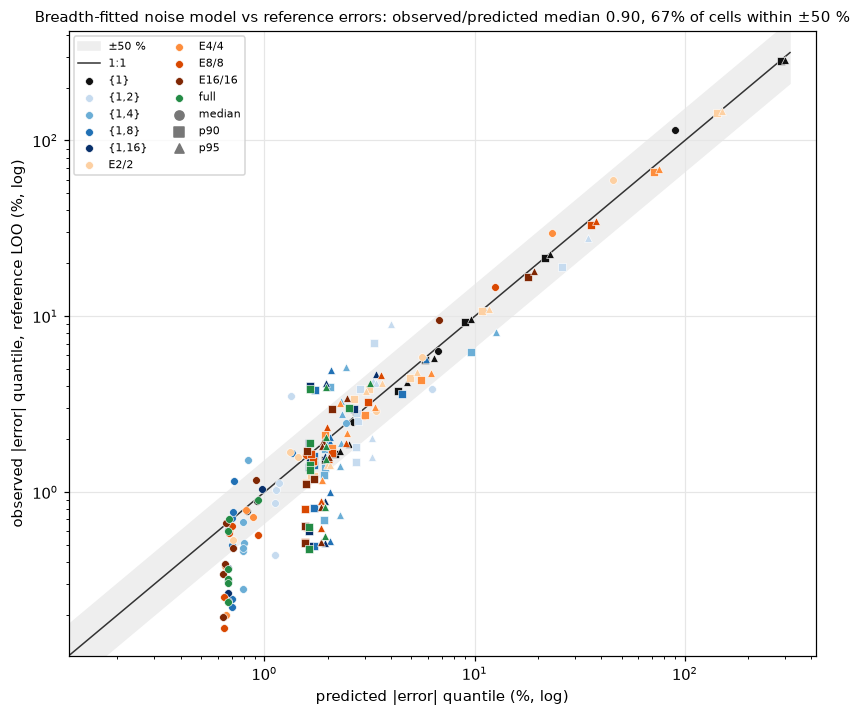

coverage of the predicted 90% interval: 89% overall; too optimistic in 2-7.5 J (obs/pred 1.67, coverage 64%); too pessimistic in 75-120 J (obs/pred 0.58, coverage 99%), >120 J (obs/pred 0.35, coverage 99%)


In [12]:
_erf = np.frompyfunc(math.erf, 1, 1)


def Phi(x):
    return 0.5 * (1 + _erf(np.asarray(x, float) / math.sqrt(2)).astype(float))


def absq(mu, sd, p, iters=60):
    """p-quantile of |X|, X ~ N(mu, sd) (vectorised bisection)."""
    mu = np.atleast_1d(np.asarray(mu, float)); sd = np.atleast_1d(np.asarray(sd, float))
    lo = np.zeros_like(mu); hi = np.abs(mu) + 10 * sd + 1e-12
    for _ in range(iters):
        mid = (lo + hi) / 2
        c = Phi((mid - mu) / sd) - Phi((-mid - mu) / sd)
        lo = np.where(c < p, mid, lo); hi = np.where(c < p, hi, mid)
    return (lo + hi) / 2


def mix_absq(mu, sd, p, iters=60):
    """p-quantile of |X| for an equal-weight mixture of N(mu_i, sd_i)."""
    mu = np.asarray(mu, float); sd = np.asarray(sd, float)
    lo, hi = 0.0, float(np.max(np.abs(mu) + 10 * sd)) + 1e-12
    for _ in range(iters):
        mid = (lo + hi) / 2
        c = np.mean(Phi((mid - mu) / sd) - Phi((-mid - mu) / sd))
        lo, hi = (mid, hi) if c < p else (lo, mid)
    return (lo + hi) / 2


def moments(b, F, d, loo_n=None):
    """relative bias and SD of config d for a query with slope b and overhead F."""
    EN = F + b * np.array(NS, float)
    sg = sigma(EN)
    Sig = RM * np.outer(sg, sg)
    w = WD[d]
    var = w @ Sig @ w
    if loo_n:                        # add the leave-one-out truth's own noise
        wf = w_full()
        var += (wf @ Sig @ wf) / loo_n
    return (w @ EN - b) / b, np.sqrt(var) / abs(b)


# validation on the reference: predicted vs observed band quantiles
PV = pd.DataFrame([dict(qid=tr["qid"], band=tr["band"], design=d,
                        **dict(zip(["mu", "sd"], moments(tr["b_true"], tr["F"], d, loo_n=9))))
                   for _, tr in TRUTH.iterrows() for d in DESIGNS])
rows = []
for (bn, d), g in PV.groupby(["band", "design"], observed=True):
    ob = ERR[(ERR["band"] == bn) & (ERR["design"] == d)]["abs"]
    for p, nm in [(0.5, "med"), (0.9, "p90"), (0.95, "p95")]:
        rows.append(dict(band=bn, design=d, stat=nm, pred=100 * mix_absq(g["mu"], g["sd"], p),
                         obs=100 * ob.quantile(p)))
CAL = pd.DataFrame(rows)
CAL["ratio"] = CAL["obs"] / CAL["pred"]
lr = np.log(CAL["ratio"])

fig, ax = plt.subplots(figsize=(7.6, 6.6))
xs = np.logspace(-2.3, 2.5, 50)
ax.fill_between(xs, xs / 1.5, xs * 1.5, color="#eeeeee", zorder=0, label="±50 %")
ax.plot(xs, xs, color="#333", lw=1, label="1:1")
for d in DESIGNS:
    for nm, mk in [("med", "o"), ("p90", "s"), ("p95", "^")]:
        s = CAL[(CAL["design"] == d) & (CAL["stat"] == nm)]
        ax.scatter(s["pred"], s["obs"], marker=mk, s=26, color=DCOLOR[d], edgecolor="white",
                   linewidth=0.4, zorder=3, label=d if nm == "med" else None)
for nm, mk in [("median", "o"), ("p90", "s"), ("p95", "^")]:
    ax.scatter([], [], marker=mk, color="#777", label=nm)
ax.set_xscale("log"); ax.set_yscale("log")
lim = [max(CAL[["pred", "obs"]].min().min() * 0.7, 5e-3), CAL[["pred", "obs"]].max().max() * 1.4]
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("predicted |error| quantile (%, log)")
ax.set_ylabel("observed |error| quantile, reference LOO (%, log)")
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.set_title(f"Breadth-fitted noise model vs reference errors: observed/predicted median "
             f"{np.exp(lr.median()):.2f}, {100 * ((CAL['ratio'] > 1 / 1.5) & (CAL['ratio'] < 1.5)).mean():.0f}% "
             f"of cells within ±50 %", fontsize=10)
fig.tight_layout(); savefig(fig, "noise_model_calibration"); plt.show()

# coverage of the predicted 90% interval, and where the model is off per band
CV_ = ERR.merge(PV[["qid", "design", "mu", "sd"]], on=["qid", "design"])
CV_["inside"] = (CV_["err"] - CV_["mu"]).abs() <= 1.645 * CV_["sd"]
COVER_ALL = 100 * CV_["inside"].mean()
BANDFIT = pd.DataFrame({
    "ratio": CAL[CAL["stat"] == "p90"].groupby("band", observed=True)["ratio"].median(),
    "cover": CV_.groupby("band", observed=True)["inside"].mean() * 100}).reindex(BAND_ORDER)
UNDER = BANDFIT[(BANDFIT["ratio"] > 1.5) | (BANDFIT["cover"] < 80)]
OVER = BANDFIT[(BANDFIT["ratio"] < 1 / 1.5) | (BANDFIT["cover"] > 97)]
FAILS = []
if len(UNDER):
    FAILS.append("too optimistic in " + ", ".join(
        f"{b} J (obs/pred {r['ratio']:.2f}, coverage {r['cover']:.0f}%)" for b, r in UNDER.iterrows()))
if len(OVER):
    FAILS.append("too pessimistic in " + ", ".join(
        f"{b} J (obs/pred {r['ratio']:.2f}, coverage {r['cover']:.0f}%)" for b, r in OVER.iterrows()))
print(f"coverage of the predicted 90% interval: {COVER_ALL:.0f}% overall; "
      + ("; ".join(FAILS) if FAILS else "calibrated in every band"))

In [13]:
# apply the model to all 250 queries. A 3-repeat F is noisy for heavy queries, so it is shrunk
# toward its worker-class median in proportion to its noise (empirical Bayes).
def se_F(b, F, n_rep, ns):
    EN = F + b * np.array(NS, float)
    sg = sigma(EN); Sig = RM * np.outer(sg, sg)
    v = -w_full(ns); v[0] += 1.0
    return np.sqrt(v @ Sig @ v / n_rep)


Q["se_F"] = [se_F(r.b, r.F, r.n_rep, [1, 2, 4, 8] if r.capped else NS) for r in Q.itertuples()]
Q["F_shr"] = Q["F"]
F_CLASS = {}
for cl, g in Q.groupby("wclass"):
    Fm = g["F"].median()
    tau2 = max(g["F"].var() - (g["se_F"] ** 2).mean(), 1e-4)
    Q.loc[g.index, "F_shr"] = Fm + (g["F"] - Fm) * tau2 / (tau2 + g["se_F"] ** 2)
    F_CLASS[cl] = Fm

PRED = pd.DataFrame([dict(tier=r.tier, qid=r.qid, band=r.band, E1=r.E1, t1=r.t1, design=d,
                          **dict(zip(["mu", "sd"], moments(r.b, r.F_shr, d))))
                     for r in Q.itertuples() for d in DESIGNS])
PRED["q50"] = absq(PRED["mu"], PRED["sd"], 0.5)
PRED["band"] = pd.Categorical(PRED["band"], BAND_ORDER, ordered=True)
best = PRED.groupby(["tier", "qid"], observed=True)["q50"].min()
FLOOR = Q.set_index(["tier", "qid"]).loc[best[best > 0.10].index, ["E1", "b"]]

## 5. Time of each config

Entry wall time is modelled from the timestamps: restart + ready (gap before the first warm-up),
gate waits, two warm-ups (the first is cold), the config's batches (`T_N = t1 × T_N/T_1`, the
median ratio per band), and a small gap between batches. The model is checked against the
measured entry durations.

In [14]:
mt = D.groupby(["tier", "qid", "N"])["t"].mean().unstack()
RAT = mt.div(mt[1], axis=0).reset_index().merge(Q[["tier", "qid", "band"]], on=["tier", "qid"])
RBAND = RAT.groupby("band", observed=True)[NS[1:]].median()
RALL = RAT[NS[1:]].median()

rows, gaps, cold = [], [], []
for tier, t in RAW.items():
    t = t.reset_index(drop=True)
    first = t.index[(t["phase"] == "warmup") & (t["batch_index"] == 1)]
    dt = t["ts"].diff().dt.total_seconds()
    for k, i in enumerate(first):
        nxt = first[k + 1] if k + 1 < len(first) else len(t)
        ent = t.iloc[i:nxt]
        gate = ent["preheat_s"].fillna(0).sum() + ent["cooldown_wait_s"].fillna(0).sum()
        rows.append(dict(tier=tier, qid=t.at[i, "qid"], gate=gate,
                         restart=(dt[i] - t.at[i, "elapsed_sec"] - gate) if i > 0 else np.nan,
                         entry_s=(t.at[nxt - 1, "ts"] - t.at[i - 1, "ts"]).total_seconds() if i > 0 else np.nan,
                         Ns=tuple(sorted(ent[ent["phase"] == "measured"]["batchnum"].astype(int)))))
        gaps += list((dt.iloc[i + 1:nxt] - t["elapsed_sec"].iloc[i + 1:nxt]).dropna())
        w1 = ent[(ent["phase"] == "warmup") & (ent["batch_index"] == 1)]
        m1 = ent[(ent["phase"] == "measured") & (ent["batchnum"] == 1)]
        if len(w1) and len(m1) and m1["failed"].iloc[0] != 1:
            cold.append(dict(tier=tier, qid=t.at[i, "qid"],
                             t_ratio=w1["elapsed_sec"].iloc[0] / m1["elapsed_sec"].iloc[0]))
ENT = pd.DataFrame(rows)
RESTART, GATE, GAP = ENT["restart"].median(), ENT["gate"].mean(), float(np.median(gaps))
COLD_BAND = (pd.DataFrame(cold).merge(Q[["tier", "qid", "band"]], on=["tier", "qid"])
             .groupby("band", observed=True)["t_ratio"].median())


def entry_seconds(t1, band, ns):
    """modelled wall time of one entry: restart + gate + 2 warm-ups + the config's batches."""
    rb = RBAND.loc[band]
    meas = sum(t1 * (1.0 if n == 1 else rb[n]) + GAP for n in ns)
    return RESTART + GATE + t1 * (COLD_BAND.loc[band] + 1) + GAP + meas


chk = ENT.dropna(subset=["entry_s"]).merge(Q[["tier", "qid", "band", "t1"]], on=["tier", "qid"])
chk["model_s"] = [entry_seconds(r.t1, r.band, r.Ns) for r in chk.itertuples()]
MODEL_ERR = 100 * abs(chk["entry_s"].mean() / chk["model_s"].mean() - 1)
print(f"restart + ready {RESTART:.1f} s, gate waits {GATE:.1f} s per entry, {1000 * GAP:.0f} ms between "
      f"batches; T_N/T_1 = " + " / ".join(f"{RALL[n]:.2f}" for n in NS[1:]) +
      f" for N = 2 / 4 / 8 / 16;  entry model vs measured durations: {MODEL_ERR:.1f}% off")

restart + ready 3.7 s, gate waits 2.8 s per entry, 77 ms between batches; T_N/T_1 = 1.95 / 3.85 / 7.65 / 14.58 for N = 2 / 4 / 8 / 16;  entry model vs measured durations: 0.2% off


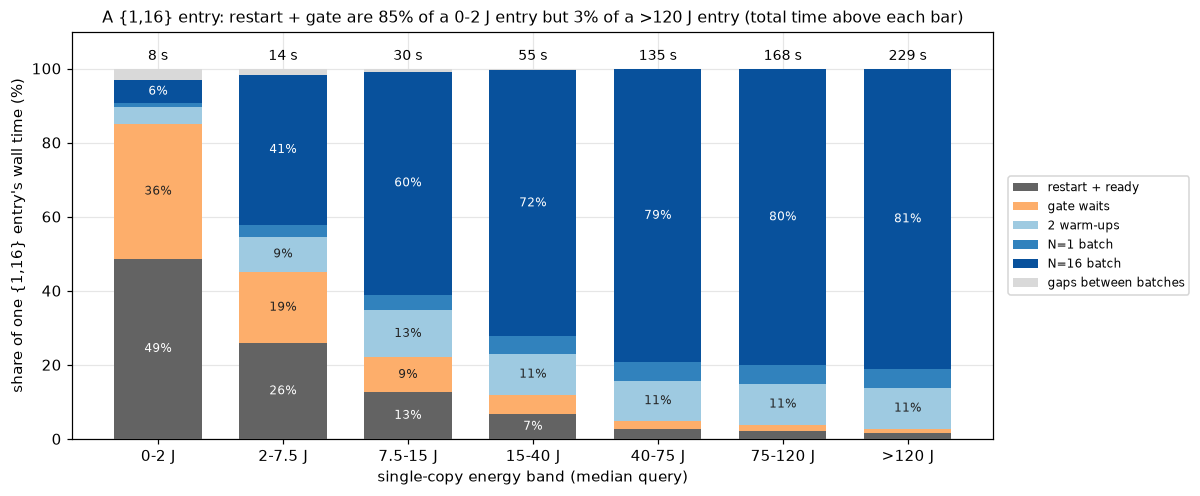

In [15]:
parts = []
for bn in BAND_ORDER:
    t1 = Q[Q["band"] == bn]["t1"].median()
    parts.append({"band": bn, "restart + ready": RESTART, "gate waits": GATE,
                  "2 warm-ups": t1 * (COLD_BAND.loc[bn] + 1), "N=1 batch": t1,
                  "N=16 batch": t1 * RBAND.loc[bn][16], "gaps between batches": 3 * GAP})
PARTS = pd.DataFrame(parts).set_index("band")
TOT = PARTS.sum(axis=1)
SH = PARTS.div(TOT, axis=0) * 100
pcol = {"restart + ready": "#636363", "gate waits": "#fdae6b", "2 warm-ups": "#9ecae1",
        "N=1 batch": "#3182bd", "N=16 batch": "#08519c", "gaps between batches": "#d9d9d9"}
fig, ax = plt.subplots(figsize=(11, 4.6))
bottom = np.zeros(len(SH))
for c in SH.columns:
    ax.bar(range(len(SH)), SH[c], bottom=bottom, color=pcol[c], label=c, width=0.7, zorder=3)
    for i, (v, b0) in enumerate(zip(SH[c], bottom)):
        if v >= 6:
            ax.text(i, b0 + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                    color="white" if c in ("restart + ready", "N=1 batch", "N=16 batch") else "#222")
    bottom += SH[c].to_numpy()
for i, tot in enumerate(TOT):
    ax.text(i, 101.5, f"{tot:.0f} s", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 110)
ax.set_xticks(range(len(SH))); ax.set_xticklabels([f"{b} J" for b in SH.index])
ax.set_xlabel("single-copy energy band (median query)")
ax.set_ylabel("share of one {1,16} entry's wall time (%)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
FIXED_SH = SH["restart + ready"] + SH["gate waits"]
ax.set_title(f"A {{1,16}} entry: restart + gate are {FIXED_SH.iloc[0]:.0f}% of a {BAND_ORDER[0]} J entry "
             f"but {FIXED_SH.iloc[-1]:.0f}% of a {BAND_ORDER[-1]} J entry (total time above each bar)",
             fontsize=10.5)
fig.tight_layout(); savefig(fig, "entry_time_breakdown"); plt.show()

**Cost of every config**, as entry wall time relative to a `{1}` entry at each band's median query
— the time counterpart of the §3 error heatmaps.

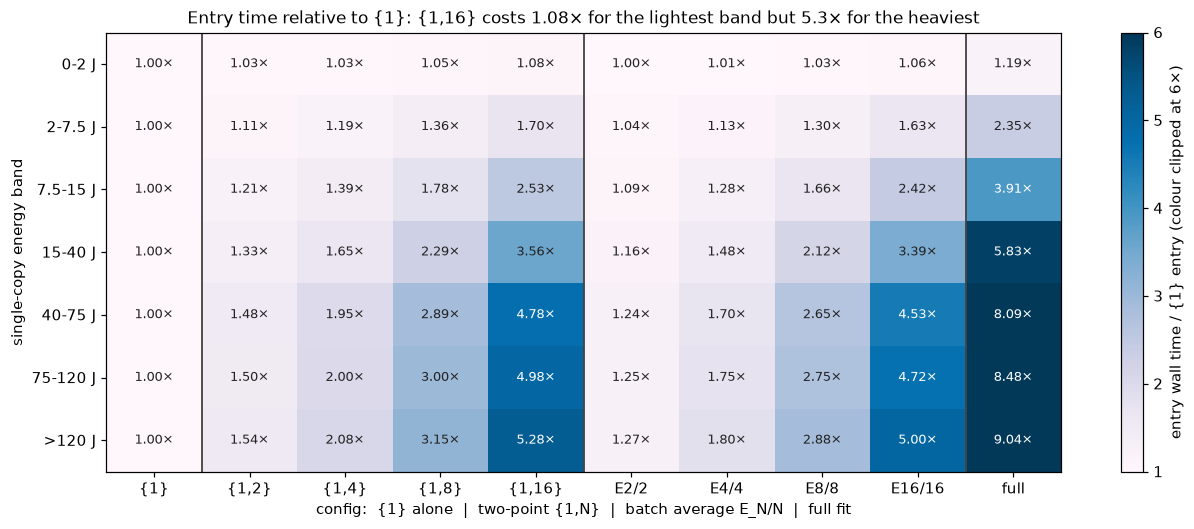

In [16]:
COST = pd.DataFrame({bn: {d: entry_seconds(Q[Q["band"] == bn]["t1"].median(), bn, DESIGN_NS[d])
                          for d in DESIGNS} for bn in BAND_ORDER})
REL = (COST / COST.loc["{1}"]).T.reindex(index=BAND_ORDER, columns=DESIGNS)
heat(REL, f"Entry time relative to {{1}}: {{1,16}} costs {REL['{1,16}'].iloc[0]:.2f}× for the "
     f"lightest band but {REL['{1,16}'].iloc[-1]:.1f}× for the heaviest", "heatmap_time",
     6, "entry wall time / {1} entry (colour clipped at 6×)", vmin=1, cmap="PuBu",
     fmt=lambda v: f"{v:.2f}×" if v < 10 else f"{v:.0f}×")

## 6. Which config to use

For each band and accuracy target (90 / 95 / 99 % = at most 10 / 5 / 1 % error), the **cheapest**
config (by §5 entry time) whose error meets the target — by the median (typical repeat) or the
p90 (9 repeats in 10). Left: from the noise model over all 250 queries. Right: directly from the
observed reference errors of §3. Colour = entry time relative to `{1}`; grey = no config meets it,
with the most accurate config underneath and the accuracy it does reach (100 % − its error at that
criterion).

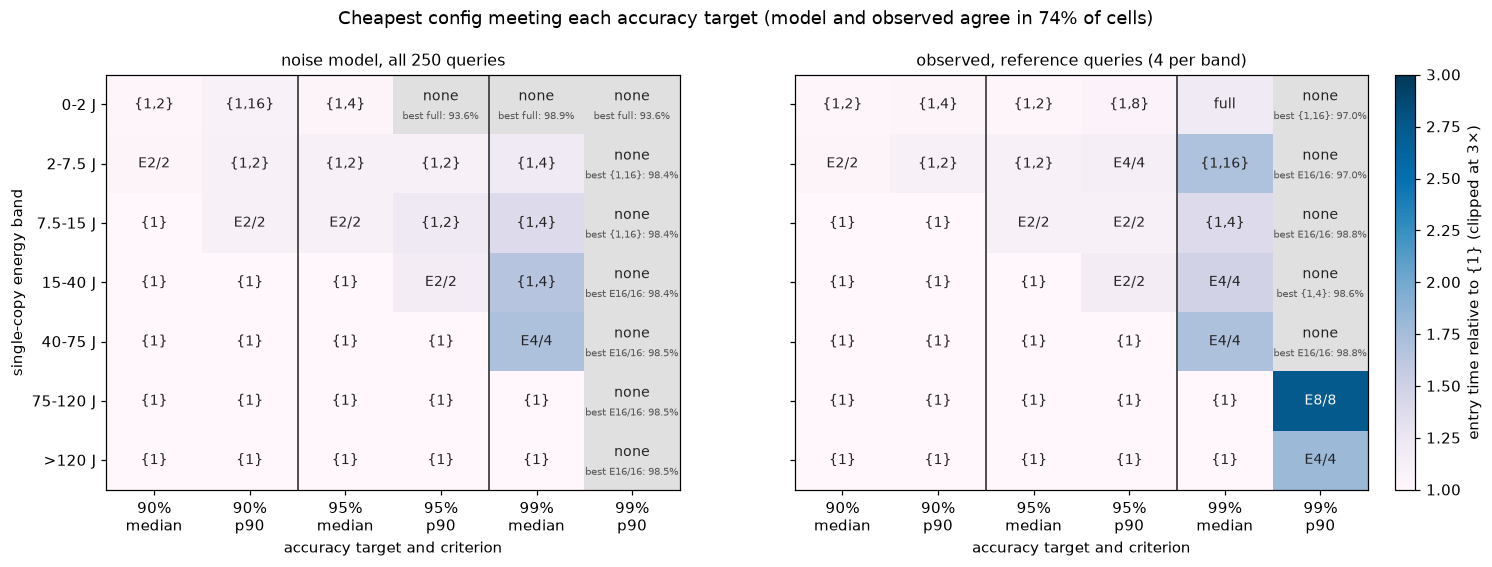

3 queries (E1 ≤ 0.39 J, b ≤ 12 mJ per copy) miss even 90% with every config per the model — their per-copy work is at the noise level (14 mJ observed; the model floor 29 mJ overstates it). They need more repeats, not a bigger batch.


In [17]:
TGT = {"90%": 0.10, "95%": 0.05, "99%": 0.01}
TCOLS = [f"{r} {c}" for r in TGT for c in ("med", "p90")]


def pick(bn, meets):
    ok = [d for d in DESIGNS if meets(d)]
    return min(ok, key=lambda d: COST.loc[d, bn]) if ok else "none"


def err_model(bn, d, p):
    g = PRED[(PRED["band"] == bn) & (PRED["design"] == d)]
    return mix_absq(g["mu"], g["sd"], p)


def err_obs(bn, d, p):
    return ERR[(ERR["band"] == bn) & (ERR["design"] == d)]["abs"].quantile(p)


# cheapest config meeting each target; where none does, record the most accurate config instead
rows, rows_obs, BEST = [], [], {}
for bn in BAND_ORDER:
    row, ro = {"band": bn}, {"band": bn}
    for r, e in TGT.items():
        for crit, p in [("med", 0.5), ("p90", 0.9)]:
            col = f"{r} {crit}"
            for src, errf, out in [("model", err_model, row), ("obs", err_obs, ro)]:
                errs = {d: errf(bn, d, p) for d in DESIGNS}
                out[col] = pick(bn, lambda d: errs[d] <= e)
                if out[col] == "none":
                    dbest = min(errs, key=errs.get)
                    BEST[(src, bn, col)] = (dbest, errs[dbest])
    rows.append(row); rows_obs.append(ro)
TIER = pd.DataFrame(rows).set_index("band")[TCOLS]
TIER_OBS = pd.DataFrame(rows_obs).set_index("band")[TCOLS]
AGREE = (TIER == TIER_OBS).to_numpy().mean() * 100

cmap = plt.cm.PuBu.copy(); cmap.set_bad("#e0e0e0")
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.9), sharey=True)
for ax, T, ttl, src in [(axes[0], TIER, "noise model, all 250 queries", "model"),
                        (axes[1], TIER_OBS, "observed, reference queries (4 per band)", "obs")]:
    ax.grid(False)
    V = np.array([[REL.loc[b, T.loc[b, c]] if T.loc[b, c] != "none" else np.nan for c in TCOLS]
                  for b in BAND_ORDER])
    im = ax.imshow(np.ma.masked_invalid(V), aspect="auto", cmap=cmap, vmin=1, vmax=3)
    for i, b in enumerate(BAND_ORDER):
        for j, c in enumerate(TCOLS):
            v = V[i, j]
            if T.loc[b, c] == "none":       # best achievable instead: most accurate config
                dbest, ebest = BEST[(src, b, c)]
                ax.text(j, i - 0.13, "none", ha="center", va="center", fontsize=9, color="#222")
                acc = math.floor(1000 * (1 - ebest)) / 10     # round down: never shows the target
                ax.text(j, i + 0.2, f"best {dbest}: {acc:.1f}%", ha="center",
                        va="center", fontsize=6.8, color="#555")
            else:
                ax.text(j, i, T.loc[b, c], ha="center", va="center", fontsize=9,
                        color="white" if np.isfinite(v) and v > 2.2 else "#222")
    ax.set_xticks(range(len(TCOLS)))
    ax.set_xticklabels([c.replace(" med", "\nmedian").replace(" p90", "\np90") for c in TCOLS])
    for xv in (1.5, 3.5):
        ax.axvline(xv, color="#444", lw=1.2)
    ax.set_xlabel("accuracy target and criterion")
    ax.set_title(ttl, fontsize=10.5)
axes[0].set_yticks(range(len(BAND_ORDER))); axes[0].set_yticklabels([f"{b} J" for b in BAND_ORDER])
axes[0].set_ylabel("single-copy energy band")
cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02); cb.set_label("entry time relative to {1} (clipped at 3×)")
fig.suptitle(f"Cheapest config meeting each accuracy target (model and observed agree in "
             f"{AGREE:.0f}% of cells)", fontsize=12, y=1.0)
savefig(fig, "best_config"); plt.show()
if len(FLOOR):
    print(f"{len(FLOOR)} queries (E1 ≤ {FLOOR['E1'].max():.2f} J, b ≤ {1000 * FLOOR['b'].max():.0f} mJ "
          f"per copy) miss even 90% with every config per the model — their per-copy work is at "
          f"the noise level ({1000 * SD_LOW:.0f} mJ observed; the model floor {1000 * S0:.0f} mJ "
          f"overstates it). They need more repeats, not a bigger batch.")

## 7. Projection to the full SQLStorm suite (only if cached)

Total wall time for all passing SQLStorm queries (not failed, not in `moved_timeouts.txt` /
`moved_errors.tsv`) with **2 repeats and 2 warm-ups**, using the §5 time model on each query's
single-copy time: a uniform `{1,16}` config vs the §6 choices per band. Bands where no config meets
a target are costed as `{1,16}` and counted.

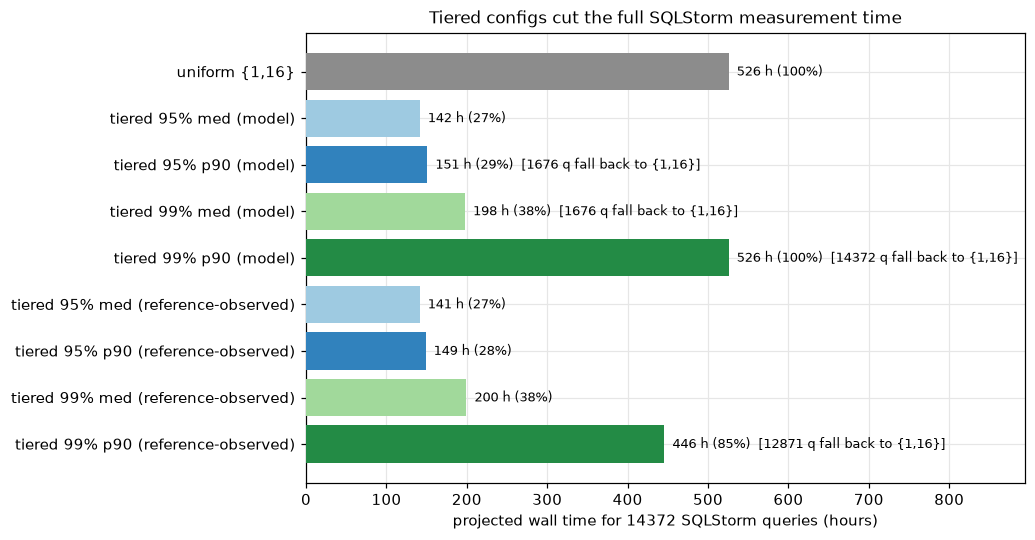

In [18]:
SS_KEYS = [f"sqlstorm/{f}" for f in SS_FILES]
if not all(k in BLOBS for k in SS_KEYS):
    PROJ = None
    print("SQLStorm files not cached — §7 skipped. Missing:", [k for k in SS_KEYS if k not in BLOBS])
else:
    ss = read("sqlstorm/query_timing_tpch_idx.csv")
    for c in ["elapsed_sec", "rapl_pkg_j", "failed"]:
        ss[c] = pd.to_numeric(ss[c], errors="coerce")
    moved = (set(BLOBS["sqlstorm/moved_timeouts.txt"].decode().split())
             | set(read("sqlstorm/moved_errors.tsv", sep="\t", header=None)[0]))
    ssm = ss[ss["phase"] == "measured"]
    ok = ssm[(ssm["failed"] != 1) & ~ssm["query"].isin(moved) & (ssm["rapl_pkg_j"] > 0)]
    SS = ok.groupby("query").agg(E1=("rapl_pkg_j", "mean"), t1=("elapsed_sec", "mean"))
    SS["band"] = pd.cut(SS["E1"], BAND_EDGES, labels=BAND_ORDER, right=False).astype(str)
    REPEATS = 2

    def hours(design_of_band):
        s, fallback = 0.0, 0
        for bn, g in SS.groupby("band"):
            d = design_of_band(bn)
            if d == "none":                # no config meets the target -> fall back to {1,16}
                d = "{1,16}"; fallback += len(g)
            s += sum(entry_seconds(t1, bn, DESIGN_NS[d]) for t1 in g["t1"])
        return REPEATS * s / 3600, fallback

    rows = [dict(design="uniform {1,16}", **dict(zip(["hours", "fallback_q"],
                                                     hours(lambda bn: "{1,16}"))))]
    for src, T in [("model", TIER), ("reference-observed", TIER_OBS)]:
        for col in ["95% med", "95% p90", "99% med", "99% p90"]:
            h, fb = hours(lambda bn, c=col, T=T: T.loc[bn, c])
            rows.append(dict(design=f"tiered {col} ({src})", hours=h, fallback_q=fb))
    PROJ = pd.DataFrame(rows).set_index("design")
    PROJ["vs uniform"] = PROJ["hours"] / PROJ.loc["uniform {1,16}", "hours"]

    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    cols = ["#8c8c8c"] + ["#9ecae1", "#3182bd", "#a1d99b", "#238b45"] * 2
    ax.barh(range(len(PROJ)), PROJ["hours"], color=cols, zorder=3)
    for i, (h, f, fb) in enumerate(zip(PROJ["hours"], PROJ["vs uniform"], PROJ["fallback_q"])):
        ax.text(h, i, f"  {h:.0f} h ({100 * f:.0f}%)" + (f"  [{fb} q fall back to {{1,16}}]"
                                                         if fb and i else ""),
                va="center", fontsize=8.5)
    ax.set_yticks(range(len(PROJ))); ax.set_yticklabels(PROJ.index); ax.invert_yaxis()
    ax.set_xlabel(f"projected wall time for {len(SS)} SQLStorm queries (hours)")
    ax.set_xlim(0, PROJ["hours"].max() * 1.7)
    ax.set_title("Tiered configs cut the full SQLStorm measurement time", fontsize=11)
    fig.tight_layout(); savefig(fig, "sqlstorm_projection"); plt.show()

### 7a. Where the hours go, by band

The same projection split by energy band, for a uniform `{1,16}`, the observed 95 % (p90) and
99 % (median) tiers of §6, and `full` everywhere.

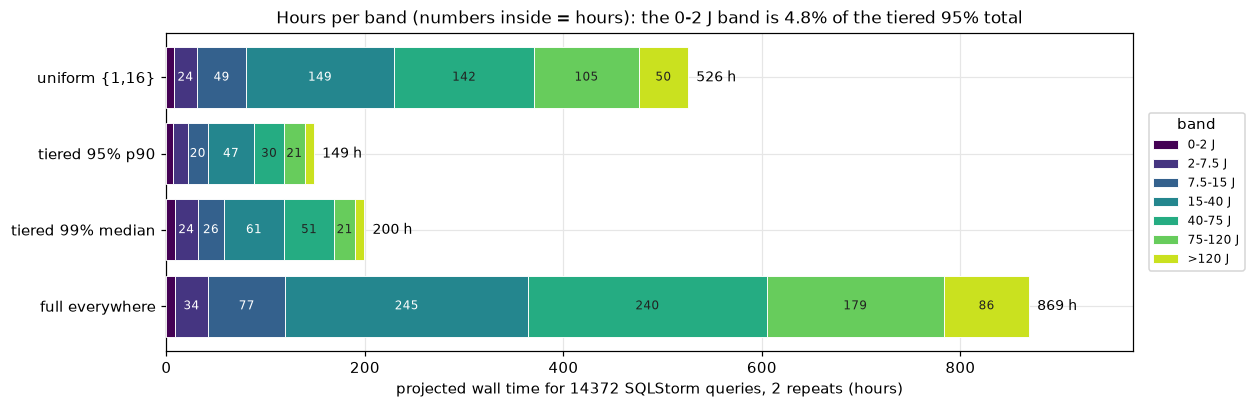

In [19]:
if PROJ is not None:
    def parts_hours(design_of_band):
        """projected hours per band, split into fixed (restart + gate), warm-ups and batches."""
        rows = []
        for bn in BAND_ORDER:
            t1 = SS.loc[SS["band"] == bn, "t1"].to_numpy()
            d = design_of_band(bn)
            d = "{1,16}" if d == "none" else d
            rb = RBAND.loc[bn]
            fixed = len(t1) * (RESTART + GATE)
            warm = (t1 * (COLD_BAND.loc[bn] + 1)).sum() + len(t1) * GAP
            batches = sum((t1 * (1.0 if n == 1 else rb[n])).sum() + len(t1) * GAP
                          for n in DESIGN_NS[d])
            rows.append(dict(band=bn, config=d, queries=len(t1),
                             **{k: REPEATS * v / 3600 for k, v in
                                [("fixed", fixed), ("warm-ups", warm), ("batches", batches)]}))
        out = pd.DataFrame(rows).set_index("band")
        out["hours"] = out[["fixed", "warm-ups", "batches"]].sum(axis=1)
        return out

    SCEN = {"uniform {1,16}": lambda bn: "{1,16}",
            "tiered 95% p90": lambda bn: TIER_OBS.loc[bn, "95% p90"],
            "tiered 99% median": lambda bn: TIER_OBS.loc[bn, "99% med"],
            "full everywhere": lambda bn: "full"}
    SB = {k: parts_hours(f) for k, f in SCEN.items()}
    assert abs(SB["uniform {1,16}"]["hours"].sum() - PROJ.loc["uniform {1,16}", "hours"]) < 1e-6

    fig, ax = plt.subplots(figsize=(11.5, 3.8))
    for i, (name, df) in enumerate(SB.items()):
        left = 0.0
        for bn in BAND_ORDER:
            h = df.loc[bn, "hours"]
            ax.barh(i, h, left=left, color=BAND_COLOR[bn], edgecolor="white", lw=0.6, zorder=3,
                    label=f"{bn} J" if i == 0 else None)
            if h >= 18:
                ax.text(left + h / 2, i, f"{h:.0f}", ha="center", va="center", fontsize=8,
                        color="white" if BAND_ORDER.index(bn) < 4 else "#222")
            left += h
        ax.text(left, i, f"  {left:.0f} h", va="center", fontsize=9)
    ax.set_yticks(range(len(SB))); ax.set_yticklabels(list(SB)); ax.invert_yaxis()
    ax.set_xlabel(f"projected wall time for {len(SS)} SQLStorm queries, 2 repeats (hours)")
    ax.set_xlim(0, max(df["hours"].sum() for df in SB.values()) * 1.12)
    ax.legend(title="band", fontsize=8, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5))
    lo_share = 100 * SB["tiered 95% p90"].loc[BAND_ORDER[0], "hours"] / SB["tiered 95% p90"]["hours"].sum()
    ax.set_title(f"Hours per band (numbers inside = hours): the {BAND_ORDER[0]} J band is "
                 f"{lo_share:.1f}% of the tiered 95% total", fontsize=11)
    fig.tight_layout(); savefig(fig, "projection_by_band"); plt.show()

### 7b. Does the config matter per band?

For each band, the projected hours of each candidate config (all of that band's SQLStorm
queries, 2 repeats), split into **fixed** restart + gate time, **warm-ups** and the measured
**batches**, cheapest first. The label on each bar is its hours and the accuracy it reaches at p90
(100 % − the observed p90 error of §3, reference queries). **T95** / **T99** mark the §6 picks for
95 % (p90) and 99 % (median). Where the fixed part dominates, a more accurate config adds almost
nothing to the total.

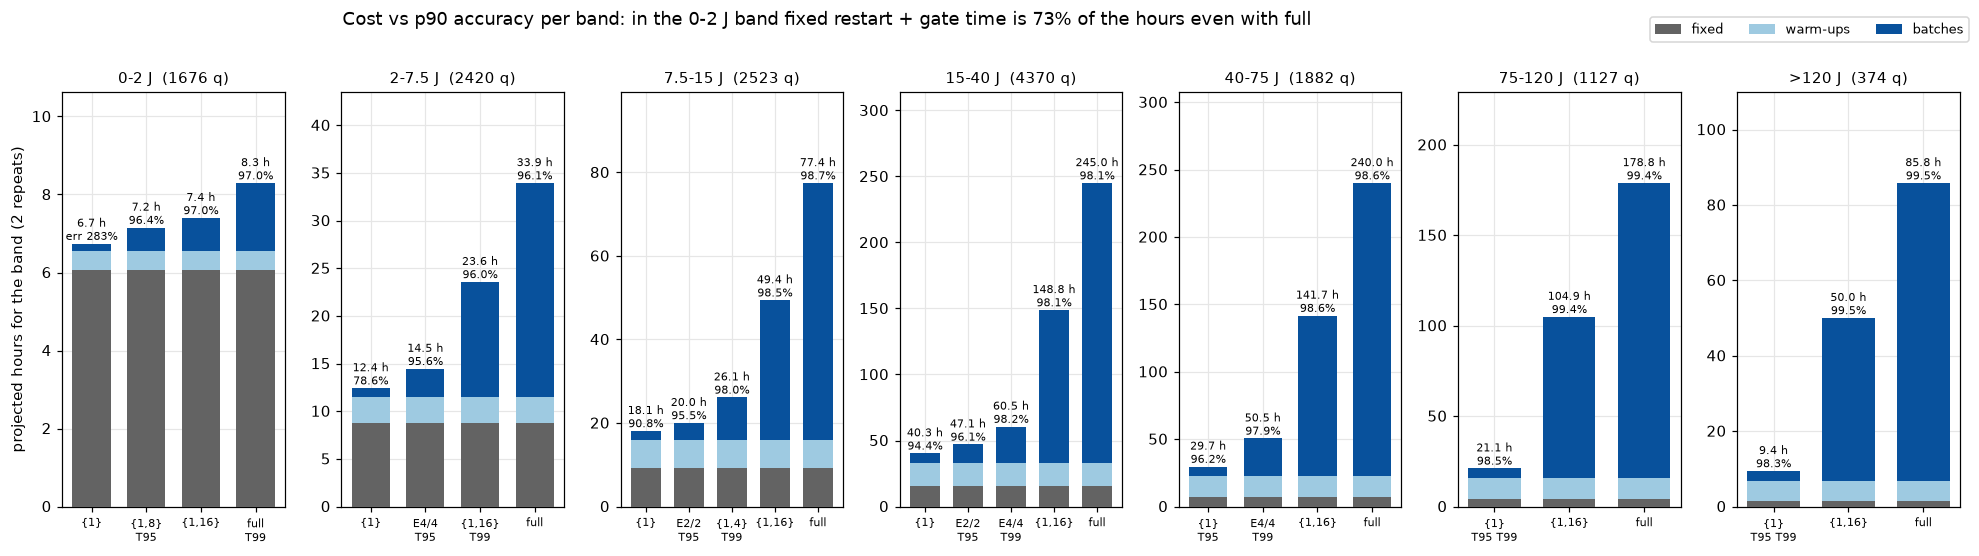

In [20]:
if PROJ is not None:
    def acc_p90(bn, d):
        return 100 * (1 - ERR[(ERR["band"] == bn) & (ERR["design"] == d)]["abs"].quantile(0.9))

    def acc_label(acc):
        return f"{acc:.1f}%" if acc >= 0 else f"err {100 - acc:.0f}%"

    PCOL = {"fixed": "#636363", "warm-ups": "#9ecae1", "batches": "#08519c"}
    fig, axes = plt.subplots(1, len(BAND_ORDER), figsize=(18, 4.9))
    for ax, bn in zip(axes, BAND_ORDER):
        tags = {}
        for d in ["{1}", "{1,16}", "full"]:
            tags.setdefault(d, [])
        tags.setdefault(TIER_OBS.loc[bn, "95% p90"], []).append("T95")
        tags.setdefault(TIER_OBS.loc[bn, "99% med"], []).append("T99")
        tags.pop("none", None)
        ph = {d: parts_hours(lambda b, d=d: d).loc[bn] for d in tags}
        cands = sorted(tags, key=lambda d: ph[d]["hours"])          # cheapest first
        for k, d in enumerate(cands):
            bottom = 0.0
            for comp in ["fixed", "warm-ups", "batches"]:
                ax.bar(k, ph[d][comp], bottom=bottom, color=PCOL[comp], width=0.7, zorder=3,
                       label=comp if (bn == BAND_ORDER[0] and k == 0) else None)
                bottom += ph[d][comp]
            ax.text(k, bottom, f"{bottom:.1f} h\n{acc_label(acc_p90(bn, d))}", ha="center",
                    va="bottom", fontsize=7.2)
        ax.set_xticks(range(len(cands)))
        ax.set_xticklabels([d + ("\n" + " ".join(tags[d]) if tags[d] else "") for d in cands],
                           fontsize=7.5)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
        ax.set_title(f"{bn} J  ({(SS['band'] == bn).sum()} q)", fontsize=10)
    axes[0].set_ylabel("projected hours for the band (2 repeats)")
    fig.legend(loc="upper right", ncol=3, fontsize=8.5, bbox_to_anchor=(1.0, 1.02))
    fx = SB["full everywhere"].loc[BAND_ORDER[0]]
    fig.suptitle(f"Cost vs p90 accuracy per band: in the {BAND_ORDER[0]} J band fixed restart + gate "
                 f"time is {100 * fx['fixed'] / fx['hours']:.0f}% of the hours even with full",
                 fontsize=12, x=0.42, y=1.02)
    fig.tight_layout(); savefig(fig, "projection_config_per_band"); plt.show()

### 7c. Price of using `full` instead of the tier pick

Extra hours if a band switches from its tier pick to `full`, with the p90 accuracy before and
after, and the extra hours as a share of the whole tiered projection.

In [21]:
if PROJ is not None:
    FULL = SB["full everywhere"]
    rows = []
    for bn in BAND_ORDER:
        r = {"band": bn, "queries": int(FULL.loc[bn, "queries"])}
        for scen, col in [("tiered 95% p90", "95% p90"), ("tiered 99% median", "99% med")]:
            d = SB[scen].loc[bn, "config"]
            extra = FULL.loc[bn, "hours"] - SB[scen].loc[bn, "hours"]
            tag = col.replace(" med", " median")
            r[f"{tag}: pick"] = d
            r[f"{tag}: +h for full"] = round(extra, 1)
            r[f"{tag}: % of total"] = round(100 * extra / SB[scen]["hours"].sum(), 1)
            r[f"{tag}: p90 acc pick → full"] = f"{acc_p90(bn, d):.1f} → {acc_p90(bn, 'full'):.1f}%"
        rows.append(r)
    FULLCOST = pd.DataFrame(rows).set_index("band")
    pd.set_option("display.width", 250)
    print(FULLCOST.to_string())
    lo = FULLCOST.loc[BAND_ORDER[0]]
    print(f"\n{BAND_ORDER[0]} J band: switching to full costs {lo['95% p90: +h for full']:+.1f} h "
          f"({lo['95% p90: % of total']:.1f}% of the tiered 95% total) over the 95% pick and "
          f"{lo['99% median: +h for full']:+.1f} h over the 99% pick, for a p90 accuracy of "
          f"{acc_p90(BAND_ORDER[0], 'full'):.1f}%.")

        queries 95% p90: pick  95% p90: +h for full  95% p90: % of total 95% p90: p90 acc pick → full 99% median: pick  99% median: +h for full  99% median: % of total 99% median: p90 acc pick → full
band                                                                                                                                                                                                   
0-2        1676         {1,8}                   1.1                  0.8                 96.4 → 97.0%             full                      0.0                     0.0                    97.0 → 97.0%
2-7.5      2420          E4/4                  19.5                 13.1                 95.6 → 96.1%           {1,16}                     10.4                     5.2                    96.0 → 96.1%
7.5-15     2523          E2/2                  57.4                 38.6                 95.5 → 98.7%            {1,4}                     51.3                    25.7                    98.0 → 98.7%
